# MindCare AI — DAIR-AI Emotion: 3-Model Controlled Comparison

**Purpose:** Fine-tune and compare exactly three Transformer sequence-classification models on the same official `dair-ai/emotion` dataset and official train/validation/test splits.

**Models:**
1. `roberta-base` — current MindCare AI reference model
2. `distilbert-base-uncased` — lightweight efficiency baseline
3. `microsoft/deberta-v3-base` — newer encoder candidate

The notebook is designed for sequential training on a Google Colab GPU and saves all outputs to Google Drive so training can resume after a Colab disconnect.

### Controlled methodology
- Same official DAIR-AI Emotion dataset and official train/validation/test splits for all three models
- Same six emotion labels
- Same maximum sequence length: 128
- Same learning rate: `2e-5`
- Same effective training batch size: 16
- Same epochs: 3
- Same random seed: 42
- Same evaluation metrics and evaluation procedure
- Primary model-selection criterion: validation Macro-F1
- Test set is used only for final descriptive comparison, not model selection

The classifier is an emotion-prediction component, not a clinical diagnostic instrument.


In [2]:
# --- Remove ONLY the packages that are known to break NumPy 2.x compatibility ---
!pip uninstall -y tensorflow opencv-python opencv-python-headless \
    opencv-contrib-python thinc numba cupy-cuda12x -q

# --- Install all dependencies WITHOUT touching torch / torchvision ---
!pip install "transformers==4.57.1" \
    "datasets>=3.0,<4" \
    "accelerate==1.10.1" \
    "scikit-learn>=1.5,<2" \
    "pandas>=2.2,<3" \
    "matplotlib>=3.8,<4" \
    "seaborn>=0.13" \
    "openpyxl>=3.1,<4" \
    "safetensors" \
    "regex" -q

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/commands/uninstall.py", line 106, in run
    uninstall_pathset = req.uninstall(
        auto_confirm=options.yes,
        verbose=self.verbosity > 0,
    )
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/req/req_install.py", line 715, in uninstall
    dist = get_default_environment().get_distribution(self.req.name)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/metadata/importlib/_envs.py", line 189, in get_distribution
    return next(matches, None)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/metadata/importlib/_envs.py", line 186, in <genexpr>
    for distribution in self.iter_all_distributions()
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/pi

In [3]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.11.0+cu130
CUDA available: True


In [4]:
# ============================================================
# CELL 2 — IMPORTS + VERSION CHECK
# ============================================================
import os
import sys
import json
import math
import time
import random
import re
import shutil
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import transformers
import datasets
import sklearn

from datasets import load_dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

warnings.filterwarnings("ignore")

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("scikit-learn:", sklearn.__version__)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is not available. In Google Colab go to "
        "Runtime -> Change runtime type -> Hardware accelerator -> GPU, "
        "then reconnect/restart and run again."
    )

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130
Transformers: 4.57.1
Datasets: 3.6.0
scikit-learn: 1.6.1
GPU: Tesla T4
CUDA: 13.0
GPU memory (GB): 15.64


In [ ]:
# Programmatically restart the Google Colab runtime session to clear memory
import os
os._exit(0)

In [7]:
# ============================================================
# CELL 3 — GOOGLE DRIVE + EXPERIMENT DIRECTORIES
# ============================================================
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison")

DIRS = {
    "results": BASE_DIR / "results",
    "models": BASE_DIR / "models",
    "reports": BASE_DIR / "reports",
    "plots": BASE_DIR / "plots",
    "logs": BASE_DIR / "logs",
    "predictions": BASE_DIR / "predictions",
    "checkpoints": BASE_DIR / "checkpoints",
    "dataset_cache": BASE_DIR / "dataset_cache",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

print("Experiment root:", BASE_DIR)
for name, path in DIRS.items():
    print(f"{name:15s} -> {path}")

Mounted at /content/drive
Experiment root: /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison
results         -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/results
models          -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/models
reports         -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/reports
plots           -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/plots
logs            -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/logs
predictions     -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/predictions
checkpoints     -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/checkpoints
dataset_cache   -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/dataset_cache


In [8]:
# ============================================================
# CELL 4 — EXPERIMENT CONFIGURATION
# ============================================================
SEED = 42

DATASET_ID = "dair-ai/emotion"

LABEL_NAMES = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise",
]

ID2LABEL = {i: name for i, name in enumerate(LABEL_NAMES)}
LABEL2ID = {name: i for i, name in enumerate(LABEL_NAMES)}
NUM_LABELS = len(LABEL_NAMES)

MODELS = {
    "roberta_base": "roberta-base",
    "distilbert_base": "distilbert-base-uncased",
    "deberta_v3_base": "microsoft/deberta-v3-base",
}

# Controlled training settings — intentionally identical across models.
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2   # effective batch = 16
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10

# Set this to False only if you deliberately want to retrain models
# whose completed artifacts already exist.
RESUME_COMPLETED_MODELS = True

# If True, continue from an incomplete Hugging Face checkpoint when one exists.
RESUME_INCOMPLETE_CHECKPOINTS = True

# Use FP16 on NVIDIA CUDA for faster/lower-memory training.
USE_FP16 = True

# Main selection criterion. Do NOT select using the test set.
PRIMARY_SELECTION_METRIC = "macro_f1"

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CONFIG = {
    "dataset_id": DATASET_ID,
    "label_names": LABEL_NAMES,
    "models": MODELS,
    "seed": SEED,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "effective_train_batch_size": TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "primary_selection_metric": PRIMARY_SELECTION_METRIC,
}

with open(DIRS["reports"] / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2)

print(json.dumps(CONFIG, indent=2))

{
  "dataset_id": "dair-ai/emotion",
  "label_names": [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
  ],
  "models": {
    "roberta_base": "roberta-base",
    "distilbert_base": "distilbert-base-uncased",
    "deberta_v3_base": "microsoft/deberta-v3-base"
  },
  "seed": 42,
  "max_length": 128,
  "learning_rate": 2e-05,
  "num_epochs": 3,
  "train_batch_size": 8,
  "gradient_accumulation_steps": 2,
  "effective_train_batch_size": 16,
  "eval_batch_size": 32,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "primary_selection_metric": "macro_f1"
}


## Expected DAIR-AI label mapping

The project report records the six-class mapping as:

| ID | Emotion |
|---:|---|
| 0 | sadness |
| 1 | joy |
| 2 | love |
| 3 | anger |
| 4 | fear |
| 5 | surprise |

The notebook verifies this mapping against the loaded dataset rather than blindly assuming it.


In [9]:
# ============================================================
# CELL 5 — LOAD OFFICIAL DAIR-AI DATASET
# ============================================================
print(f"Loading: {DATASET_ID}")

dataset = load_dataset(DATASET_ID, cache_dir=str(DIRS["dataset_cache"]))

print(dataset)
for split in ["train", "validation", "test"]:
    print(split, len(dataset[split]), dataset[split].column_names)

assert set(["train", "validation", "test"]).issubset(dataset.keys()), \
    "Expected train/validation/test splits were not found."

assert dataset["train"].column_names[:2] == ["text", "label"] or \
       set(["text", "label"]).issubset(dataset["train"].column_names), \
    "Expected text and label columns were not found."

assert len(dataset["train"]) == 16000, f"Unexpected train size: {len(dataset['train'])}"
assert len(dataset["validation"]) == 2000, f"Unexpected validation size: {len(dataset['validation'])}"
assert len(dataset["test"]) == 2000, f"Unexpected test size: {len(dataset['test'])}"

print("\nSplit sizes verified:")
print("Train      :", len(dataset["train"]))
print("Validation :", len(dataset["validation"]))
print("Test       :", len(dataset["test"]))

Loading: dair-ai/emotion


README.md: 0.00B [00:00, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
train 16000 ['text', 'label']
validation 2000 ['text', 'label']
test 2000 ['text', 'label']

Split sizes verified:
Train      : 16000
Validation : 2000
Test       : 2000


In [10]:
# ============================================================
# CELL 6 — DATASET / LABEL SANITY CHECK
# ============================================================
all_labels = set()
for split in ["train", "validation", "test"]:
    labels = set(dataset[split]["label"])
    all_labels.update(labels)
    print(f"{split:10s} labels:", sorted(labels))

assert all_labels == set(range(NUM_LABELS)),     f"Unexpected labels found: {sorted(all_labels)}"

# Verify dataset feature names where available.
print("\nDataset label feature:")
try:
    print(dataset["train"].features["label"])
except Exception as e:
    print("Could not display label feature:", e)

# Basic null / empty-text checks
for split in ["train", "validation", "test"]:
    texts = dataset[split]["text"]
    empty_count = sum(1 for x in texts if not isinstance(x, str) or not x.strip())
    print(f"{split:10s} empty/non-string text rows:", empty_count)
    assert empty_count == 0

print("\nLabel mapping used for this experiment:")
print(json.dumps(ID2LABEL, indent=2))


train      labels: [0, 1, 2, 3, 4, 5]
validation labels: [0, 1, 2, 3, 4, 5]
test       labels: [0, 1, 2, 3, 4, 5]

Dataset label feature:
ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)
train      empty/non-string text rows: 0
validation empty/non-string text rows: 0
test       empty/non-string text rows: 0

Label mapping used for this experiment:
{
  "0": "sadness",
  "1": "joy",
  "2": "love",
  "3": "anger",
  "4": "fear",
  "5": "surprise"
}


,split,label_id,emotion,count
0,train,0,sadness,4666
1,train,1,joy,5362
2,train,2,love,1304
3,train,3,anger,2159
4,train,4,fear,1937
5,train,5,surprise,572
6,validation,0,sadness,550
7,validation,1,joy,704
8,validation,2,love,178
9,validation,3,anger,275


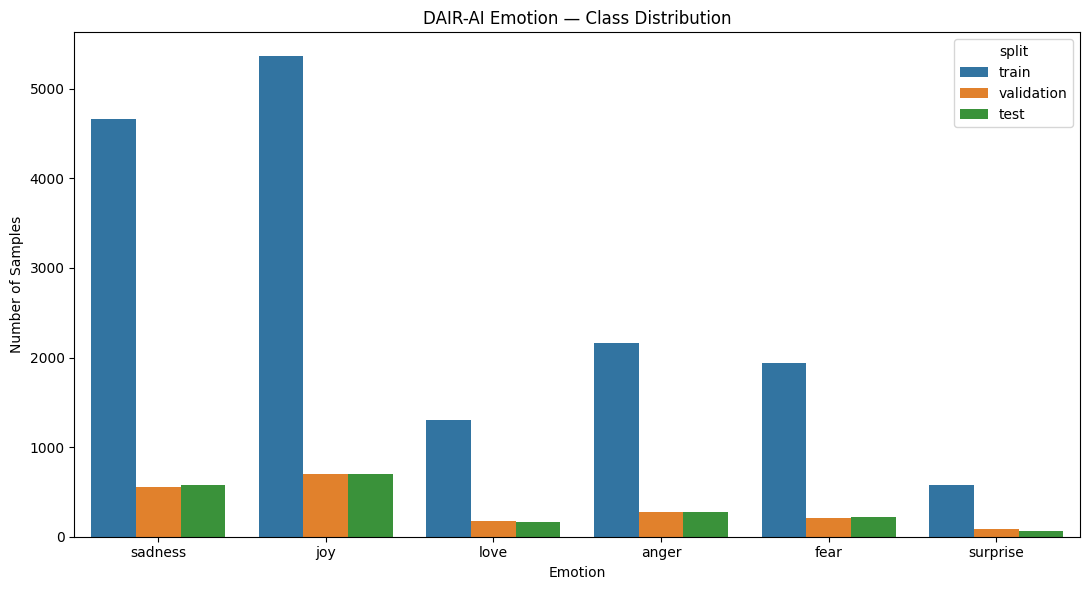

In [11]:
# ============================================================
# CELL 7 — DATASET CLASS DISTRIBUTION
# ============================================================
dist_rows = []

for split in ["train", "validation", "test"]:
    counts = pd.Series(dataset[split]["label"]).value_counts().sort_index()
    for label_id in range(NUM_LABELS):
        dist_rows.append({
            "split": split,
            "label_id": label_id,
            "emotion": ID2LABEL[label_id],
            "count": int(counts.get(label_id, 0)),
        })

distribution_df = pd.DataFrame(dist_rows)
display(distribution_df)

distribution_df.to_csv(
    DIRS["reports"] / "dataset_class_distribution.csv",
    index=False
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=distribution_df,
    x="emotion",
    y="count",
    hue="split",
)
plt.title("DAIR-AI Emotion — Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(DIRS["plots"] / "dataset_class_distribution.png", dpi=200)
plt.show()


In [12]:
# ============================================================
# CELL 8 — SAMPLE DATA INSPECTION
# ============================================================
sample_df = pd.DataFrame(dataset["train"][:10])
display(sample_df[["text", "label"]])

print("\nRandom examples:")
display(
    pd.DataFrame(dataset["train"])
    .sample(10, random_state=SEED)[["text", "label"]]
    .assign(emotion=lambda d: d["label"].map(ID2LABEL))
)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2



Random examples:


,text,label,emotion
8756,ive made it through a week i just feel beaten ...,0,sadness
4660,i feel this strategy is worthwhile,1,joy
6095,i feel so worthless and weak what does he have...,0,sadness
304,i feel clever nov,1,joy
8241,im moved in ive been feeling kind of gloomy,0,sadness
9577,i allowed myself to feel the really shitty fee...,0,sadness
1035,i feel confused too,4,fear
9976,i feel like a crappy mummy if were stuck in bu...,0,sadness
7872,i feel like i liked my hair much better before...,2,love
8341,i feel the self pressured expectation to keep ...,4,fear


In [13]:
# ============================================================
# CELL 9 — TOKENIZATION HELPER
# ============================================================
def tokenize_dataset_for_model(raw_dataset, tokenizer):
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )

    tokenized = raw_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
        desc="Tokenizing",
    )

    # Trainer expects the target under "labels" or can infer from "label".
    # Rename explicitly for clarity.
    if "label" in tokenized["train"].column_names:
        tokenized = tokenized.rename_column("label", "labels")

    return tokenized


def build_model(model_name):
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=False,
    )


In [14]:
# ============================================================
# CELL 10 — METRICS
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_precision),
        "weighted_recall": float(weighted_recall),
        "weighted_f1": float(weighted_f1),
    }


def clean_metric_dict(d):
    out = {}
    for k, v in d.items():
        if isinstance(v, (np.floating, np.integer)):
            v = v.item()
        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            continue
        out[k] = v
    return out


In [15]:
# ============================================================
# CELL 11 — TRAINING ARGUMENTS COMPATIBILITY HELPER
# ============================================================
import inspect
import math

def make_training_arguments(output_dir, logging_dir):
    # Dynamically calculate warmup_steps to match WARMUP_RATIO (10% of total steps)
    # Total training steps = (num_samples * epochs) / (batch_size * grad_accumulation)
    num_train_samples = 16000
    effective_batch_size = TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
    total_steps = math.ceil((num_train_samples * NUM_EPOCHS) / effective_batch_size)
    calculated_warmup_steps = int(math.ceil(total_steps * WARMUP_RATIO))

    common = dict(
        output_dir=str(output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=calculated_warmup_steps,
        lr_scheduler_type="linear",
        logging_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model=PRIMARY_SELECTION_METRIC,
        greater_is_better=True,
        fp16=USE_FP16,
        seed=SEED,
        data_seed=SEED,
        dataloader_num_workers=2,
        report_to="none",
        optim="adamw_torch",
        remove_unused_columns=True,
    )
    params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in params:
        common["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in params:
        common["evaluation_strategy"] = "epoch"
    else:
        raise RuntimeError("This Transformers version has no supported evaluation-strategy parameter.")
    return TrainingArguments(**common)

In [16]:
import transformers
import inspect
from transformers import TrainingArguments

print("Transformers version:", transformers.__version__)

params = inspect.signature(TrainingArguments.__init__).parameters

print("\nSupported warmup parameters:")
for p in ["warmup_ratio", "warmup_steps"]:
    print(p, "->", p in params)

Transformers version: 4.57.1

Supported warmup parameters:
warmup_ratio -> True
warmup_steps -> True


In [22]:
# ============================================================
# CELL 12 — ARTIFACT / RESUME HELPERS
# ============================================================
def model_root(model_key):
    return DIRS["models"] / model_key


def result_root(model_key):
    return DIRS["results"] / model_key


def checkpoint_root(model_key):
    return DIRS["checkpoints"] / model_key


def completed_marker(model_key):
    return result_root(model_key) / "COMPLETED.json"


def save_json(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def is_completed(model_key):
    if not RESUME_COMPLETED_MODELS:
        return False
    return completed_marker(model_key).exists() and            (model_root(model_key) / "config.json").exists()


def find_latest_checkpoint(model_key):
    ckpt_dir = checkpoint_root(model_key)
    if not ckpt_dir.exists():
        return None

    candidates = []
    for p in ckpt_dir.glob("checkpoint-*"):
        if p.is_dir():
            m = re.search(r"checkpoint-(\d+)$", p.name)
            if m:
                candidates.append((int(m.group(1)), p))

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]


def get_model_parameter_count(model):
    return int(sum(p.numel() for p in model.parameters()))


In [17]:
# ============================================================
# CELL 13 — DETAILED EVALUATION + ARTIFACT SAVING
# ============================================================
def evaluate_and_save(trainer, model_key, tokenized_split, raw_split, split_name):
    result_dir = result_root(model_key)
    result_dir.mkdir(parents=True, exist_ok=True)

    metrics = trainer.evaluate(eval_dataset=tokenized_split, metric_key_prefix=split_name)
    metrics = clean_metric_dict(metrics)
    save_json(metrics, result_dir / f"{split_name}_metrics.json")

    prediction_output = trainer.predict(tokenized_split, metric_key_prefix=split_name)
    logits = prediction_output.predictions
    labels = prediction_output.label_ids
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    confidences = probs.max(axis=1)

    raw_texts = raw_split["text"]
    rows = []
    for i, (true_id, pred_id, conf) in enumerate(zip(labels, preds, confidences)):
        rows.append({
            "index": i,
            "true_label_id": int(true_id),
            "true_emotion": ID2LABEL[int(true_id)],
            "pred_label_id": int(pred_id),
            "pred_emotion": ID2LABEL[int(pred_id)],
            "confidence": float(conf),
            "correct": bool(int(true_id) == int(pred_id)),
            "text": raw_texts[i],
        })

    pred_df = pd.DataFrame(rows)
    pred_df.to_csv(DIRS["predictions"] / f"{model_key}_{split_name}_predictions.csv", index=False)
    wrong_df = pred_df[~pred_df["correct"]].copy()
    wrong_df.to_csv(DIRS["predictions"] / f"{model_key}_{split_name}_wrong_predictions.csv", index=False)

    report_dict = classification_report(
        labels, preds, labels=list(range(NUM_LABELS)), target_names=LABEL_NAMES,
        output_dict=True, zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index":"class"})
    report_df.to_csv(result_dir / f"{split_name}_classification_report.csv", index=False)

    cm = confusion_matrix(labels, preds, labels=list(range(NUM_LABELS)))
    cm_df = pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES)
    cm_df.to_csv(result_dir / f"{split_name}_confusion_matrix.csv")
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    pd.DataFrame(cm_norm, index=LABEL_NAMES, columns=LABEL_NAMES).to_csv(
        result_dir / f"{split_name}_normalized_confusion_matrix.csv"
    )

    plt.figure(figsize=(8,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, cmap="Blues")
    plt.title(f"{model_key} — {split_name.title()} Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
    plt.savefig(result_dir / f"{split_name}_confusion_matrix.png", dpi=220); plt.close()

    plt.figure(figsize=(8,6)); sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, cmap="Blues", vmin=0, vmax=1)
    plt.title(f"{model_key} — {split_name.title()} Normalized Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
    plt.savefig(result_dir / f"{split_name}_normalized_confusion_matrix.png", dpi=220); plt.close()

    class_only = report_df[report_df["class"].isin(LABEL_NAMES)].copy()
    plt.figure(figsize=(10,6)); sns.barplot(data=class_only, x="class", y="f1-score"); plt.ylim(0,1)
    plt.title(f"{model_key} — {split_name.title()} Per-Class F1"); plt.xlabel("Emotion"); plt.ylabel("F1"); plt.xticks(rotation=20); plt.tight_layout()
    plt.savefig(result_dir / f"{split_name}_per_class_f1.png", dpi=220); plt.close()

    return {"metrics":metrics,"predictions":pred_df,"wrong_predictions":wrong_df,"classification_report":report_df,"confusion_matrix":cm_df}


In [18]:
# ============================================================
# CELL 14 — TRAIN ONE MODEL
# ============================================================
def train_one_model(model_key, model_name):
    print("\n" + "=" * 80)
    print(f"STARTING MODEL: {model_key} | {model_name}")
    print("=" * 80)

    result_dir = result_root(model_key)
    model_dir = model_root(model_key)
    ckpt_dir = checkpoint_root(model_key)
    log_dir = DIRS["logs"] / model_key

    result_dir.mkdir(parents=True, exist_ok=True)
    model_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------------
    # Skip a model only when the complete artifact exists.
    # --------------------------------------------------------
    if is_completed(model_key):
        print("Completed artifacts already exist. Skipping retraining.")
        with open(completed_marker(model_key), "r", encoding="utf-8") as f:
            completed_info = json.load(f)
        return completed_info

    started = time.time()

    # --------------------------------------------------------
    # Tokenizer + model
    # --------------------------------------------------------
    print("Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    print("Tokenizing dataset...")
    tokenized = tokenize_dataset_for_model(dataset, tokenizer)

    print("Loading base model...")
    model = build_model(model_name)

    parameter_count = get_model_parameter_count(model)
    parameter_millions = parameter_count / 1e6

    print(f"Parameters: {parameter_count:,} ({parameter_millions:.2f}M)")

    # --------------------------------------------------------
    # Data collator
    # --------------------------------------------------------
    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
        pad_to_multiple_of=8 if torch.cuda.is_available() else None,
    )

    # --------------------------------------------------------
    # Training arguments
    # --------------------------------------------------------
    training_args = make_training_arguments(
        output_dir=ckpt_dir,
        logging_dir=log_dir,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    # --------------------------------------------------------
    # Resume if a checkpoint exists.
    # --------------------------------------------------------
    resume_checkpoint = None
    if RESUME_INCOMPLETE_CHECKPOINTS:
        resume_checkpoint = find_latest_checkpoint(model_key)

    if resume_checkpoint is not None:
        print("Resuming from:", resume_checkpoint)
    else:
        print("No incomplete checkpoint found. Starting from base model.")

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------
    train_output = trainer.train(
        resume_from_checkpoint=str(resume_checkpoint)
        if resume_checkpoint is not None
        else None
    )

    train_metrics = clean_metric_dict(train_output.metrics)
    save_json(train_metrics, result_dir / "train_metrics.json")

    # --------------------------------------------------------
    # Save final/best model + tokenizer
    # --------------------------------------------------------
    print("Saving best/final selected model...")
    trainer.save_model(str(model_dir))
    tokenizer.save_pretrained(str(model_dir))

    save_json(ID2LABEL, model_dir / "label_mapping.json")

    # --------------------------------------------------------
    # Validation evaluation
    # --------------------------------------------------------
    print("Evaluating validation set...")
    validation_artifacts = evaluate_and_save(
        trainer,
        model_key,
        tokenized["validation"],
        dataset["validation"],
        "validation",
    )

    # --------------------------------------------------------
    # Test evaluation — final held-out comparison
    # --------------------------------------------------------
    print("Evaluating test set...")
    test_artifacts = evaluate_and_save(
        trainer,
        model_key,
        tokenized["test"],
        dataset["test"],
        "test",
    )

    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------
    history = []
    for row in trainer.state.log_history:
        cleaned = {}
        for k, v in row.items():
            if isinstance(v, (np.floating, np.integer)):
                v = v.item()
            cleaned[k] = v
        history.append(cleaned)

    save_json(history, result_dir / "training_log_history.json")
    pd.DataFrame(history).to_csv(
        result_dir / "training_log_history.csv",
        index=False
    )

    # Training curves
    history_df = pd.DataFrame(history)

    if not history_df.empty:
        plt.figure(figsize=(10, 6))
        if "loss" in history_df.columns:
            train_rows = history_df[history_df["loss"].notna()]
            if not train_rows.empty:
                plt.plot(
                    train_rows["epoch"],
                    train_rows["loss"],
                    marker="o",
                    label="Training loss",
                )

        if "eval_loss" in history_df.columns:
            eval_rows = history_df[history_df["eval_loss"].notna()]
            if not eval_rows.empty:
                plt.plot(
                    eval_rows["epoch"],
                    eval_rows["eval_loss"],
                    marker="o",
                    label="Validation loss",
                )

        plt.title(f"{model_key} — Training / Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(result_dir / "training_validation_loss.png", dpi=220)
        plt.close()

        plt.figure(figsize=(10, 6))
        if "eval_macro_f1" in history_df.columns:
            eval_rows = history_df[history_df["eval_macro_f1"].notna()]
            if not eval_rows.empty:
                plt.plot(
                    eval_rows["epoch"],
                    eval_rows["eval_macro_f1"],
                    marker="o",
                    label="Validation Macro-F1",
                )

        if "eval_accuracy" in history_df.columns:
            eval_rows = history_df[history_df["eval_accuracy"].notna()]
            if not eval_rows.empty:
                plt.plot(
                    eval_rows["epoch"],
                    eval_rows["eval_accuracy"],
                    marker="o",
                    label="Validation Accuracy",
                )

        plt.title(f"{model_key} — Validation Metrics by Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.savefig(result_dir / "validation_metrics.png", dpi=220)
        plt.close()

    elapsed = time.time() - started

    experiment_info = {
        "model_key": model_key,
        "base_model": model_name,
        "dataset": DATASET_ID,
        "seed": SEED,
        "max_length": MAX_LENGTH,
        "learning_rate": LEARNING_RATE,
        "epochs_configured": NUM_EPOCHS,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "effective_train_batch_size": TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "parameter_count": parameter_count,
        "parameter_millions": parameter_millions,
        "training_time_seconds": elapsed,
        "training_time_minutes": elapsed / 60,
        "validation_metrics": validation_artifacts["metrics"],
        "test_metrics": test_artifacts["metrics"],
        "model_path": str(model_dir),
        "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    }

    save_json(experiment_info, result_dir / "experiment_metadata.json")
    save_json(experiment_info, completed_marker(model_key))

    # Free GPU memory before next model.
    del trainer
    del model
    del tokenizer
    del tokenized
    torch.cuda.empty_cache()

    print(f"Finished {model_key} in {elapsed/60:.2f} minutes.")
    return experiment_info


In [25]:
# ============================================================
# CELL 15 — TRAIN ALL THREE MODELS SEQUENTIALLY
# ============================================================
all_results = {}

for model_key, model_name in MODELS.items():
    result = train_one_model(model_key, model_name)
    all_results[model_key] = result

    # Keep a live summary after each model so a disconnect does not
    # lose the information already completed.
    live_summary = []
    for key, info in all_results.items():
        live_summary.append({
            "model_key": key,
            "base_model": info.get("base_model"),
            "validation_macro_f1": info.get("validation_metrics", {}).get("validation_macro_f1"),
            "test_accuracy": info.get("test_metrics", {}).get("test_accuracy"),
            "test_macro_f1": info.get("test_metrics", {}).get("test_macro_f1"),
            "test_weighted_f1": info.get("test_metrics", {}).get("test_weighted_f1"),
            "training_time_min": info.get("training_time_minutes"),
        })

    pd.DataFrame(live_summary).to_csv(
        DIRS["reports"] / "live_three_model_summary.csv",
        index=False
    )

print("\nAll requested models processed.")



STARTING MODEL: roberta_base | roberta-base
Completed artifacts already exist. Skipping retraining.

STARTING MODEL: distilbert_base | distilbert-base-uncased
Completed artifacts already exist. Skipping retraining.

STARTING MODEL: deberta_v3_base | microsoft/deberta-v3-base
Completed artifacts already exist. Skipping retraining.

All requested models processed.


In [26]:
# ============================================================
# CELL 16 — RELOAD ALL COMPLETED RESULTS FROM DRIVE
# ============================================================
def reload_completed_results():
    rows = []

    for model_key, model_name in MODELS.items():
        meta_path = result_root(model_key) / "experiment_metadata.json"

        if not meta_path.exists():
            print("Missing metadata:", model_key)
            continue

        with open(meta_path, "r", encoding="utf-8") as f:
            info = json.load(f)

        val = info.get("validation_metrics", {})
        test = info.get("test_metrics", {})

        rows.append({
            "model_key": model_key,
            "base_model": model_name,
            "parameters_M": info.get("parameter_millions"),
            "validation_accuracy": val.get("validation_accuracy"),
            "validation_macro_f1": val.get("validation_macro_f1"),
            "validation_weighted_f1": val.get("validation_weighted_f1"),
            "test_accuracy": test.get("test_accuracy"),
            "test_macro_precision": test.get("test_macro_precision"),
            "test_macro_recall": test.get("test_macro_recall"),
            "test_macro_f1": test.get("test_macro_f1"),
            "test_weighted_precision": test.get("test_weighted_precision"),
            "test_weighted_recall": test.get("test_weighted_recall"),
            "test_weighted_f1": test.get("test_weighted_f1"),
            "training_time_min": info.get("training_time_minutes"),
        })

    return pd.DataFrame(rows)


comparison_df = reload_completed_results()

if len(comparison_df) != len(MODELS):
    print("WARNING: Not all three models have completed artifacts yet.")
    display(comparison_df)
else:
    print("All three model result files found.")

display(comparison_df)
comparison_df.to_csv(
    DIRS["reports"] / "three_model_comparison.csv",
    index=False
)


All three model result files found.


,model_key,base_model,parameters_M,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1,training_time_min
0,roberta_base,roberta-base,124.650246,0.9390,0.911824,0.938750,0.9300,0.898411,0.866651,0.880224,0.929183,0.9300,0.928727,8.451196
1,distilbert_base,distilbert-base-uncased,66.958086,0.9400,0.913600,0.940051,0.9260,0.883716,0.881352,0.882037,0.926618,0.9260,0.926051,5.977228
2,deberta_v3_base,microsoft/deberta-v3-base,184.426758,0.9405,0.912974,0.940333,0.9355,0.904693,0.883570,0.892921,0.935129,0.9355,0.934909,15.356949


In [27]:
# ============================================================
# CELL 17 — SELECT PRODUCTION MODEL USING VALIDATION MACRO-F1
# ============================================================
if len(comparison_df) < len(MODELS):
    raise RuntimeError(
        "All three models must finish before selecting the production model."
    )

selection_df = comparison_df.sort_values(
    by="validation_macro_f1",
    ascending=False,
).reset_index(drop=True)

selected_row = selection_df.iloc[0]
selected_model_key = selected_row["model_key"]
selected_base_model = selected_row["base_model"]

selected_model_info = {
    "selection_rule": "Highest validation Macro-F1",
    "selected_model_key": selected_model_key,
    "selected_base_model": selected_base_model,
    "validation_macro_f1": float(selected_row["validation_macro_f1"]),
    "test_accuracy_descriptive_only": float(selected_row["test_accuracy"]),
    "test_macro_f1_descriptive_only": float(selected_row["test_macro_f1"]),
    "model_path": str(model_root(selected_model_key)),
    "note": (
        "The test-set values are reported descriptively and were not used "
        "to select or tune the production model."
    ),
}

save_json(
    selected_model_info,
    DIRS["reports"] / "selected_model.json"
)

print("=" * 80)
print("SELECTED PRODUCTION MODEL")
print("=" * 80)
print("Model key :", selected_model_key)
print("Base model:", selected_base_model)
print("Val Macro-F1:", round(float(selected_row["validation_macro_f1"]), 4))
print("Saved path:", model_root(selected_model_key))


SELECTED PRODUCTION MODEL
Model key : distilbert_base
Base model: distilbert-base-uncased
Val Macro-F1: 0.9136
Saved path: /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/models/distilbert_base


In [28]:
# ============================================================
# CELL 18 — TEST-ACCURACY LEADER (DESCRIPTIVE ONLY)
# ============================================================
test_accuracy_leader = comparison_df.sort_values(
    by="test_accuracy",
    ascending=False,
).iloc[0]

test_accuracy_leader_info = {
    "descriptive_metric": "test_accuracy",
    "leader_model_key": test_accuracy_leader["model_key"],
    "leader_base_model": test_accuracy_leader["base_model"],
    "test_accuracy": float(test_accuracy_leader["test_accuracy"]),
    "warning": (
        "This is a descriptive held-out test result. It was NOT used "
        "to select the production model."
    ),
}

save_json(
    test_accuracy_leader_info,
    DIRS["reports"] / "test_accuracy_leader.json"
)

print(
    "Highest test accuracy (descriptive only):",
    test_accuracy_leader["model_key"],
    f"({test_accuracy_leader['test_accuracy']:.4f})"
)


Highest test accuracy (descriptive only): deberta_v3_base (0.9355)


In [29]:
# ============================================================
# CELL 19 — FINAL COMPARISON TABLE
# ============================================================
display(
    comparison_df.sort_values(
        "validation_macro_f1",
        ascending=False
    ).style.format({
        "parameters_M": "{:.2f}",
        "validation_accuracy": "{:.4f}",
        "validation_macro_f1": "{:.4f}",
        "validation_weighted_f1": "{:.4f}",
        "test_accuracy": "{:.4f}",
        "test_macro_precision": "{:.4f}",
        "test_macro_recall": "{:.4f}",
        "test_macro_f1": "{:.4f}",
        "test_weighted_precision": "{:.4f}",
        "test_weighted_recall": "{:.4f}",
        "test_weighted_f1": "{:.4f}",
        "training_time_min": "{:.2f}",
    })
)

comparison_df.to_csv(
    DIRS["reports"] / "final_three_model_comparison.csv",
    index=False
)


,model_key,base_model,parameters_M,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1,training_time_min
1,distilbert_base,distilbert-base-uncased,66.96,0.9400,0.9136,0.9401,0.9260,0.8837,0.8814,0.8820,0.9266,0.9260,0.9261,5.98
2,deberta_v3_base,microsoft/deberta-v3-base,184.43,0.9405,0.9130,0.9403,0.9355,0.9047,0.8836,0.8929,0.9351,0.9355,0.9349,15.36
0,roberta_base,roberta-base,124.65,0.9390,0.9118,0.9387,0.9300,0.8984,0.8667,0.8802,0.9292,0.9300,0.9287,8.45


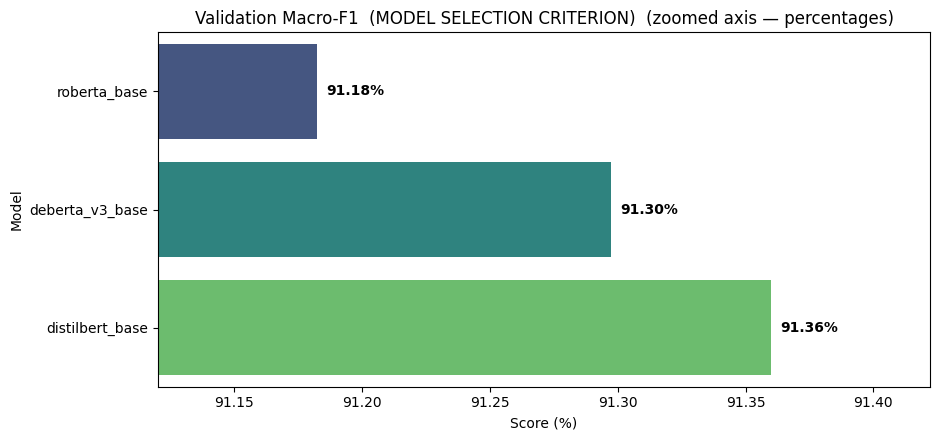

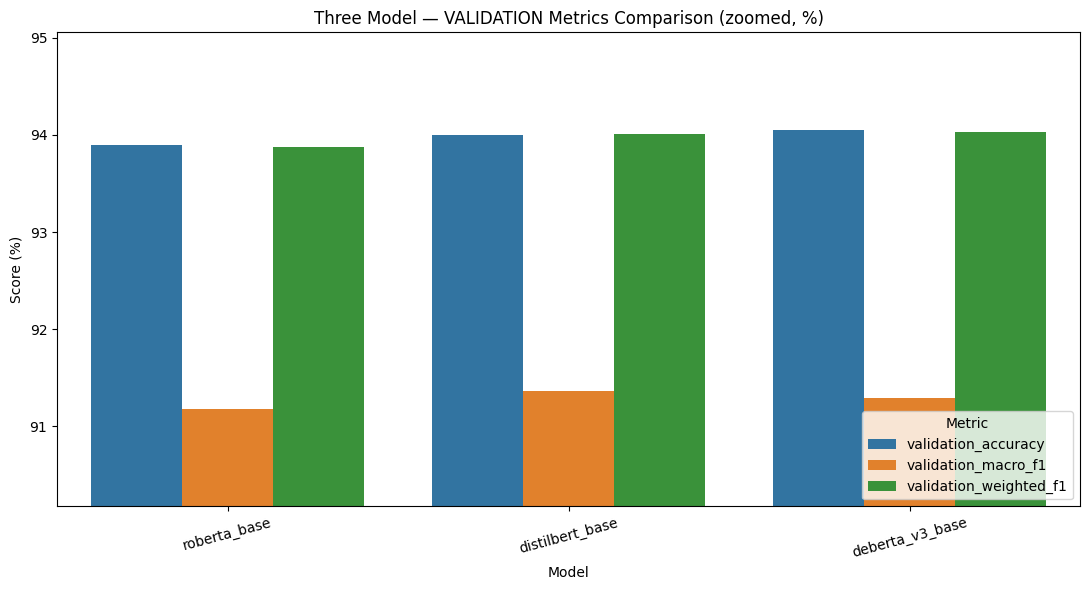

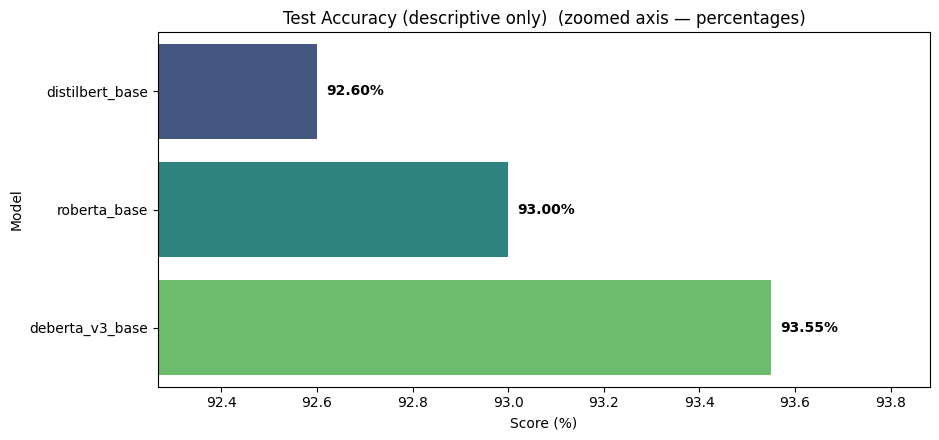

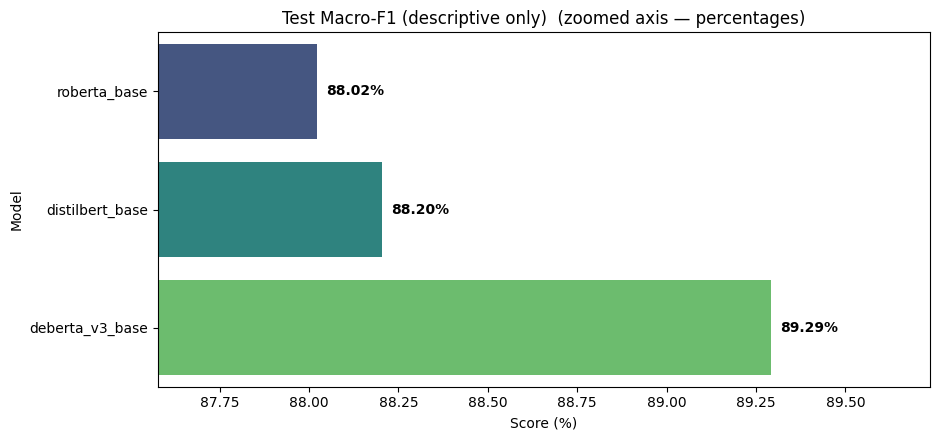

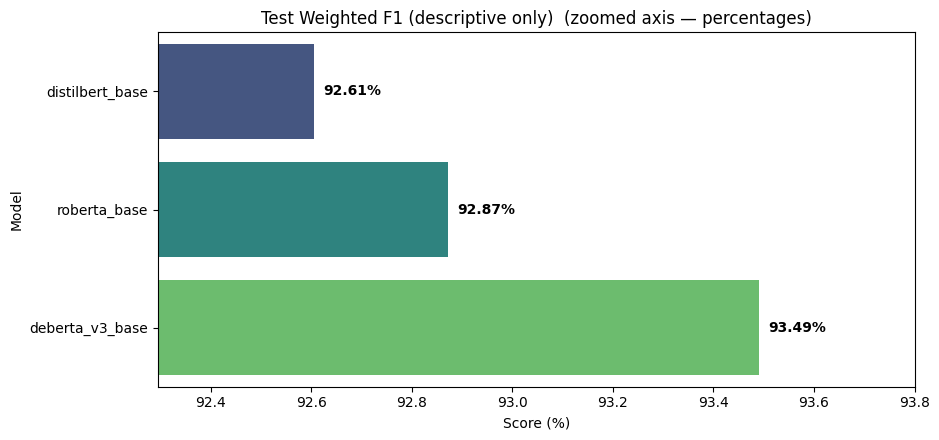

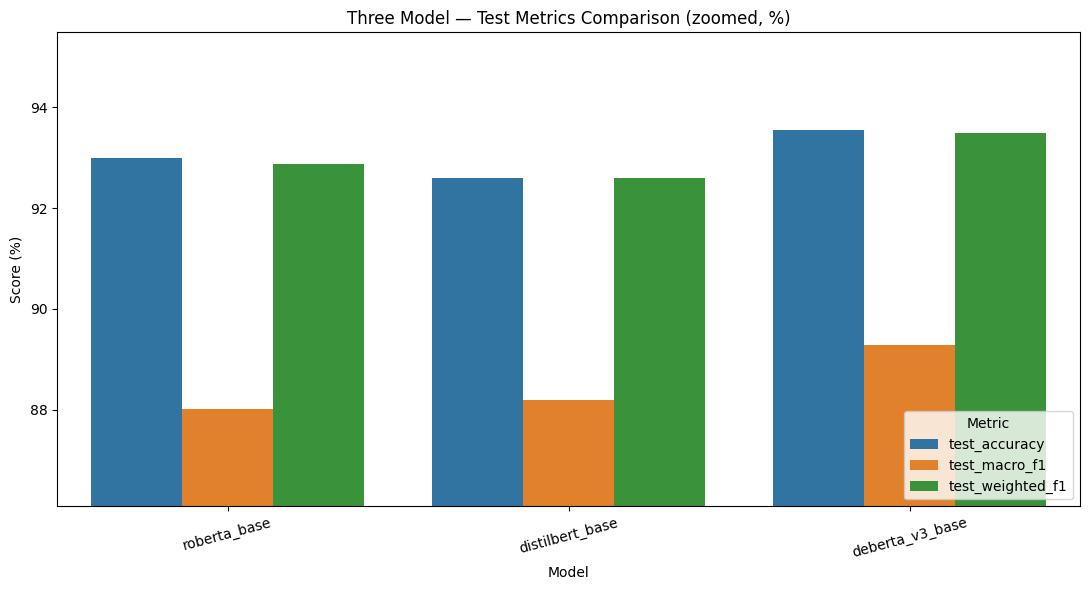

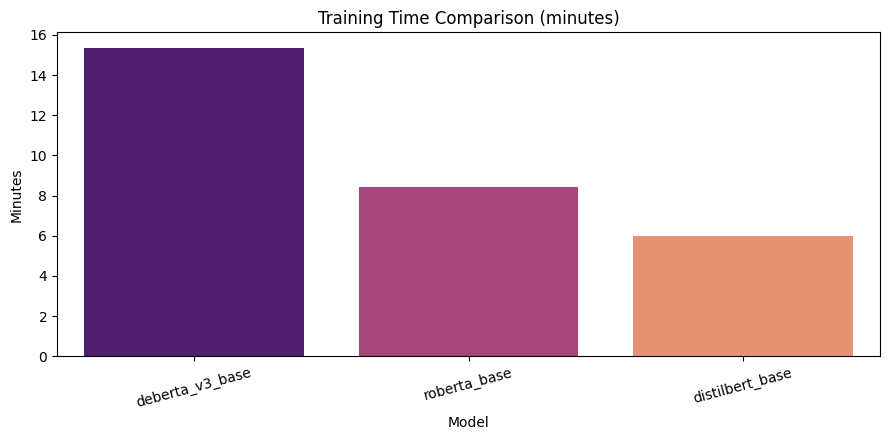

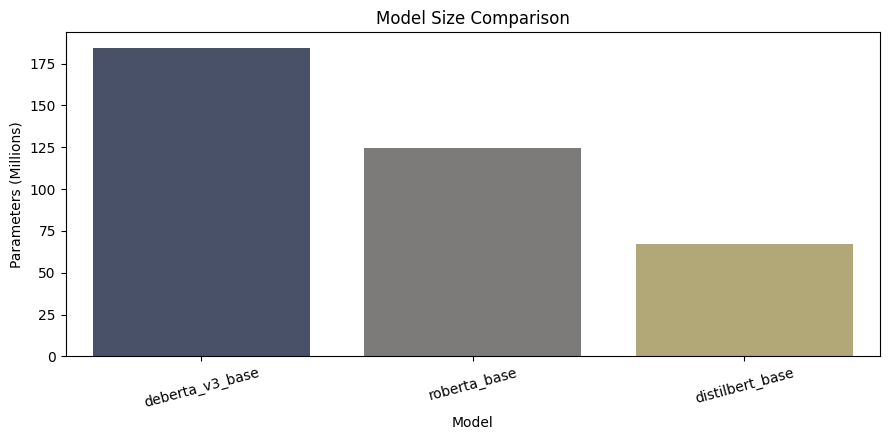

In [30]:
# ============================================================
# CELL 20 — COMPARISON GRAPHS (PERCENTAGE + ZOOMED Y-AXIS)
#          Includes VALIDATION Macro-F1 (the selection metric)
# ============================================================
plot_df = comparison_df.copy()

# Convert all rate-metrics to percentages
pct_metrics = [
    "validation_accuracy", "validation_macro_f1", "validation_weighted_f1",
    "test_accuracy", "test_macro_f1", "test_weighted_f1",
]
for m in pct_metrics:
    if m in plot_df.columns:
        plot_df[m + "_pct"] = plot_df[m] * 100.0


def zoomed_pct_barh(data, value_col, title, save_name, xlabel="Score (%)"):
    """Horizontal bar chart with zoomed x-axis + percentage labels."""
    df = data.sort_values(value_col, ascending=True).copy()
    lo, hi = df[value_col].min(), df[value_col].max()
    pad = max(0.05, (hi - lo) * 0.35)

    plt.figure(figsize=(9.5, 4.5))
    ax = sns.barplot(data=df, x=value_col, y="model_key", palette="viridis")
    ax.set_xlim(lo - pad, hi + pad)
    plt.title(title + "  (zoomed axis — percentages)")
    plt.xlabel(xlabel)
    plt.ylabel("Model")

    for i, v in enumerate(df[value_col]):
        ax.text(v + (hi - lo) * 0.02, i, f"{v:.2f}%",
                va="center", fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.savefig(DIRS["plots"] / save_name, dpi=220)
    plt.show()


# ============================================================
# ★ SELECTION METRIC — VALIDATION MACRO-F1 ★
# ============================================================
zoomed_pct_barh(
    plot_df,
    "validation_macro_f1_pct",
    "Validation Macro-F1  (MODEL SELECTION CRITERION)",
    "comparison_validation_macro_f1_pct.png",
)

# --- Validation metrics — grouped view ---
long_val = plot_df.melt(
    id_vars=["model_key"],
    value_vars=["validation_accuracy_pct",
                "validation_macro_f1_pct",
                "validation_weighted_f1_pct"],
    var_name="metric", value_name="score_pct",
)
long_val["metric"] = long_val["metric"].str.replace("_pct", "", regex=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=long_val, x="model_key", y="score_pct", hue="metric")
lo, hi = long_val["score_pct"].min(), long_val["score_pct"].max()
pad = max(0.05, (hi - lo) * 0.35)
ax.set_ylim(lo - pad, hi + pad)
plt.title("Three Model — VALIDATION Metrics Comparison (zoomed, %)")
plt.xlabel("Model"); plt.ylabel("Score (%)")
plt.xticks(rotation=15)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(DIRS["plots"] / "comparison_all_validation_metrics_pct.png", dpi=220)
plt.show()


# ============================================================
# Descriptive test-set metrics
# ============================================================
zoomed_pct_barh(plot_df, "test_accuracy_pct",
                "Test Accuracy (descriptive only)",
                "comparison_test_accuracy_pct.png")

zoomed_pct_barh(plot_df, "test_macro_f1_pct",
                "Test Macro-F1 (descriptive only)",
                "comparison_test_macro_f1_pct.png")

zoomed_pct_barh(plot_df, "test_weighted_f1_pct",
                "Test Weighted F1 (descriptive only)",
                "comparison_test_weighted_f1_pct.png")

long_te = plot_df.melt(
    id_vars=["model_key"],
    value_vars=["test_accuracy_pct", "test_macro_f1_pct", "test_weighted_f1_pct"],
    var_name="metric", value_name="score_pct",
)
long_te["metric"] = long_te["metric"].str.replace("_pct", "", regex=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=long_te, x="model_key", y="score_pct", hue="metric")
lo, hi = long_te["score_pct"].min(), long_te["score_pct"].max()
pad = max(0.05, (hi - lo) * 0.35)
ax.set_ylim(lo - pad, hi + pad)
plt.title("Three Model — Test Metrics Comparison (zoomed, %)")
plt.xlabel("Model"); plt.ylabel("Score (%)")
plt.xticks(rotation=15)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(DIRS["plots"] / "comparison_all_test_metrics_pct.png", dpi=220)
plt.show()


# --- Training time (minutes, no % needed) ---
plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=plot_df.sort_values("training_time_min", ascending=False),
    x="model_key", y="training_time_min", palette="magma",
)
plt.title("Training Time Comparison (minutes)")
plt.xlabel("Model"); plt.ylabel("Minutes")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(DIRS["plots"] / "comparison_training_time.png", dpi=220)
plt.show()


# --- Parameter count ---
plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=plot_df.sort_values("parameters_M", ascending=False),
    x="model_key", y="parameters_M", palette="cividis",
)
plt.title("Model Size Comparison")
plt.xlabel("Model"); plt.ylabel("Parameters (Millions)")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(DIRS["plots"] / "comparison_parameter_count.png", dpi=220)
plt.show()

,class,precision,recall,f1-score,support
0,sadness,0.9592,0.9707,0.9649,581
1,joy,0.9547,0.9410,0.9478,695
2,love,0.8144,0.8553,0.8344,159
3,anger,0.9427,0.8982,0.9199,275
4,fear,0.8608,0.9107,0.8850,224
5,surprise,0.7705,0.7121,0.7402,66


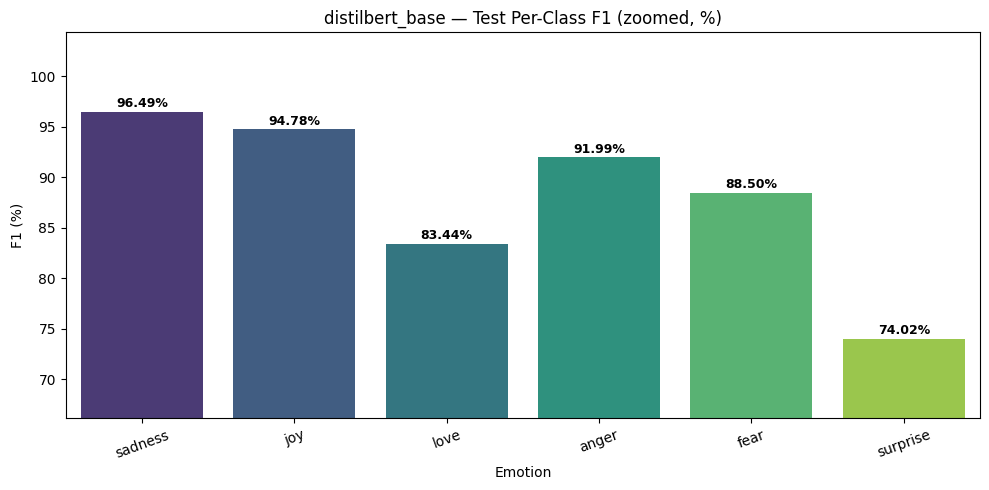

In [31]:
# ============================================================
# CELL 21 — BEST MODEL: PER-CLASS F1 (ZOOMED, %)
# ============================================================
best_key = selected_model_key
best_result_dir = result_root(best_key)

best_report = pd.read_csv(best_result_dir / "test_classification_report.csv")
best_class_report = best_report[best_report["class"].isin(LABEL_NAMES)].copy()
best_class_report["f1_pct"] = best_class_report["f1-score"] * 100.0

display(
    best_class_report[["class", "precision", "recall", "f1-score", "support"]]
    .style.format({
        "precision": "{:.4f}", "recall": "{:.4f}",
        "f1-score": "{:.4f}", "support": "{:.0f}",
    })
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=best_class_report, x="class", y="f1_pct", palette="viridis")
lo, hi = best_class_report["f1_pct"].min(), best_class_report["f1_pct"].max()
pad = max(0.2, (hi - lo) * 0.35)
ax.set_ylim(lo - pad, hi + pad)
plt.title(f"{best_key} — Test Per-Class F1 (zoomed, %)")
plt.xlabel("Emotion"); plt.ylabel("F1 (%)")
plt.xticks(rotation=20)

for i, v in enumerate(best_class_report["f1_pct"]):
    ax.text(i, v + (hi - lo) * 0.02, f"{v:.2f}%",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(DIRS["plots"] / "BEST_MODEL_per_class_f1_pct.png", dpi=220)
plt.show()

,sadness,joy,love,anger,fear,surprise
sadness,564,4,0,7,6,0
joy,1,654,31,4,1,4
love,0,23,136,0,0,0
anger,15,2,0,247,11,0
fear,6,0,0,4,204,10
surprise,2,2,0,0,15,47


,sadness,joy,love,anger,fear,surprise
sadness,0.970740,0.006885,0.000000,0.012048,0.010327,0.000000
joy,0.001439,0.941007,0.044604,0.005755,0.001439,0.005755
love,0.000000,0.144654,0.855346,0.000000,0.000000,0.000000
anger,0.054545,0.007273,0.000000,0.898182,0.040000,0.000000
fear,0.026786,0.000000,0.000000,0.017857,0.910714,0.044643
surprise,0.030303,0.030303,0.000000,0.000000,0.227273,0.712121


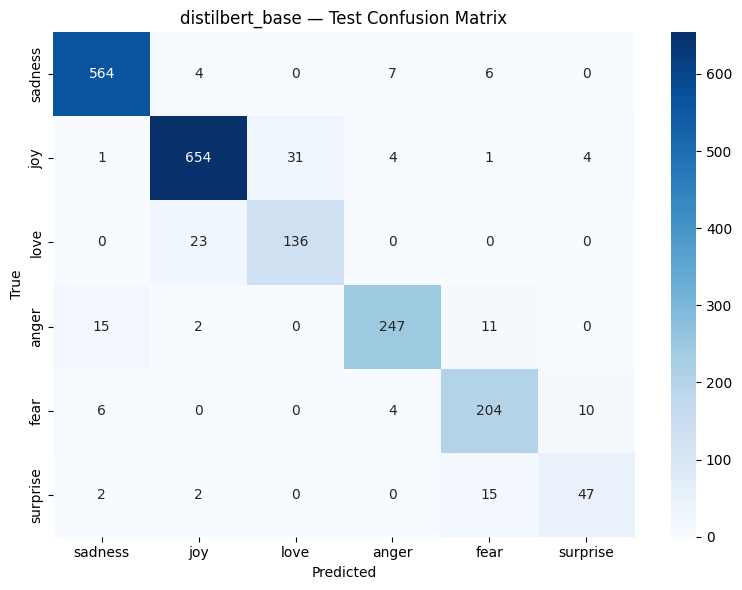

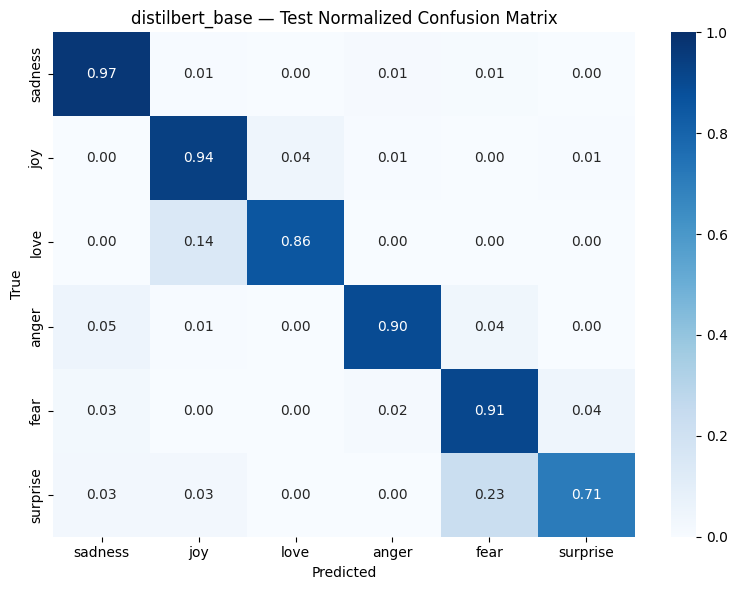

In [32]:
# ============================================================
# CELL 22 — BEST MODEL CONFUSION MATRICES
# ============================================================
cm = pd.read_csv(
    best_result_dir / "test_confusion_matrix.csv",
    index_col=0,
)

cm_norm = pd.read_csv(
    best_result_dir / "test_normalized_confusion_matrix.csv",
    index_col=0,
)

display(cm)
display(cm_norm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
plt.title(f"{best_key} — Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(DIRS["plots"] / "BEST_MODEL_confusion_matrix.png", dpi=220)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
plt.title(f"{best_key} — Test Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(DIRS["plots"] / "BEST_MODEL_normalized_confusion_matrix.png", dpi=220)
plt.show()


In [33]:
# ============================================================
# CELL 23 — BEST MODEL ERROR ANALYSIS
# ============================================================
wrong_path = DIRS["predictions"] / f"{best_key}_test_wrong_predictions.csv"

wrong_df = pd.read_csv(wrong_path)

print("Total wrong predictions:", len(wrong_df))
display(wrong_df.head(30))

error_summary = (
    wrong_df
    .groupby(["true_emotion", "pred_emotion"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_summary)

error_summary.to_csv(
    DIRS["reports"] / "BEST_MODEL_error_summary.csv",
    index=False
)

# Most difficult true classes by recall
best_class_report_sorted = best_class_report.sort_values(
    "recall",
    ascending=True
)

print("\nLowest-recall emotion classes:")
display(
    best_class_report_sorted[
        ["class", "precision", "recall", "f1-score", "support"]
    ].head()
)


Total wrong predictions: 148


,index,true_label_id,true_emotion,pred_label_id,pred_emotion,confidence,correct,text
0,10,4,fear,3,anger,0.861574,False,i don t feel particularly agitated
1,40,3,anger,0,sadness,0.573201,False,i feel if i completely hated things i d exerci...
2,67,3,anger,0,sadness,0.772596,False,i feel a bit stressed even though all the thin...
3,72,5,surprise,4,fear,0.596928,False,i am right handed however i play billiards lef...
4,86,1,joy,2,love,0.858711,False,i feel like i am in paradise kissing those swe...
5,93,4,fear,5,surprise,0.540737,False,i was feeling weird the other day and it went ...
6,94,3,anger,4,fear,0.819301,False,when a friend dropped a frog down my neck
7,98,3,anger,4,fear,0.761542,False,i feel my heart is tortured by what i have done
8,111,2,love,1,joy,0.610438,False,i feel is he generous
9,131,2,love,1,joy,0.960503,False,im feeling generous today heres one more you m...


,true_emotion,pred_emotion,count
8,joy,love,31
11,love,joy,23
15,surprise,fear,15
2,anger,sadness,15
0,anger,fear,11
5,fear,surprise,10
12,sadness,anger,7
13,sadness,fear,6
4,fear,sadness,6
10,joy,surprise,4



Lowest-recall emotion classes:


,class,precision,recall,f1-score,support
5,surprise,0.770492,0.712121,0.740157,66.0
2,love,0.814371,0.855346,0.834356,159.0
3,anger,0.942748,0.898182,0.919926,275.0
4,fear,0.860759,0.910714,0.885033,224.0
1,joy,0.954745,0.941007,0.947826,695.0


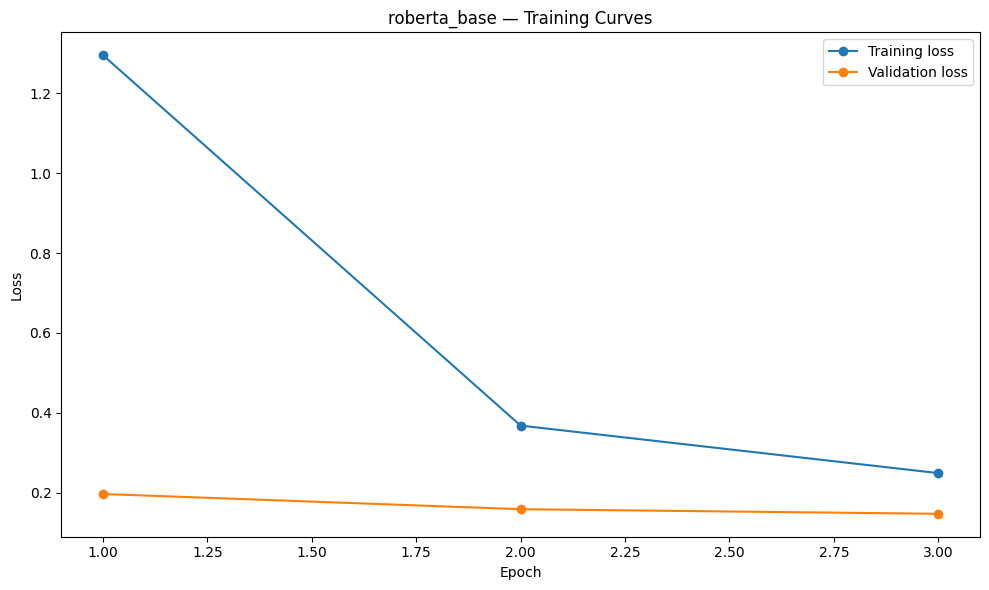

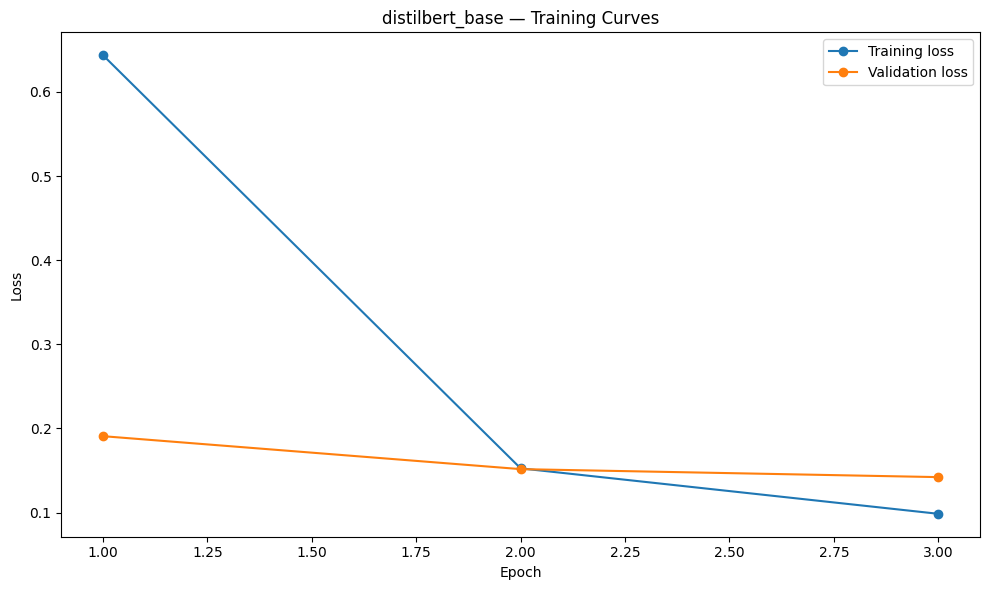

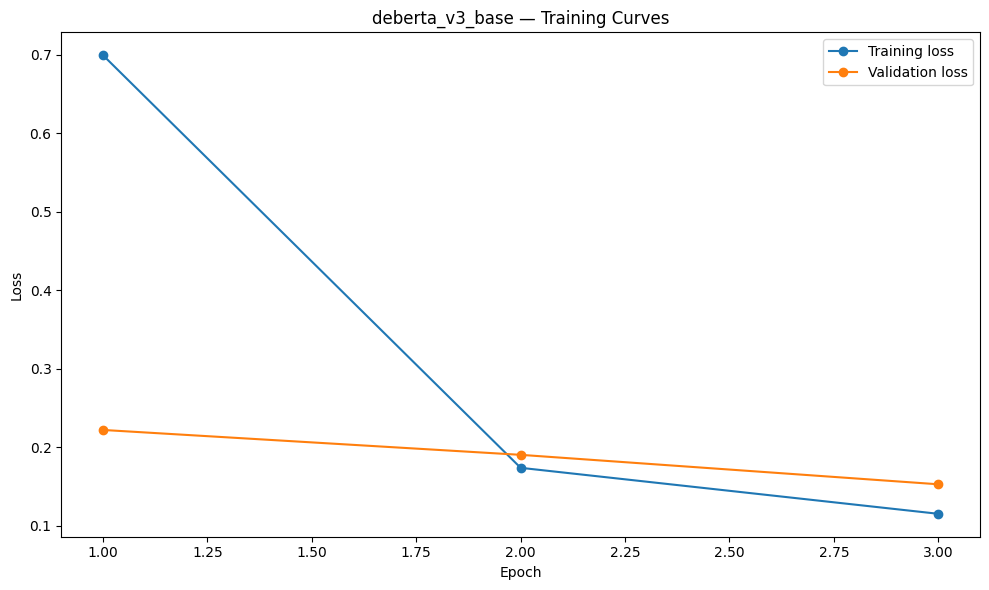

In [34]:
# ============================================================
# CELL 24 — TRAINING CURVES FOR ALL MODELS
# ============================================================
for model_key in MODELS:
    history_path = result_root(model_key) / "training_log_history.csv"

    if not history_path.exists():
        print("Missing history:", model_key)
        continue

    h = pd.read_csv(history_path)

    plt.figure(figsize=(10, 6))

    if "loss" in h.columns:
        train_rows = h[h["loss"].notna()]
        if not train_rows.empty:
            plt.plot(
                train_rows["epoch"],
                train_rows["loss"],
                marker="o",
                label="Training loss",
            )

    if "eval_loss" in h.columns:
        eval_rows = h[h["eval_loss"].notna()]
        if not eval_rows.empty:
            plt.plot(
                eval_rows["epoch"],
                eval_rows["eval_loss"],
                marker="o",
                label="Validation loss",
            )

    plt.title(f"{model_key} — Training Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        DIRS["plots"] / f"{model_key}_training_curves.png",
        dpi=220,
    )
    plt.show()


In [ ]:
# ============================================================
# CELL 25 — CREATE EXCEL WORKBOOK
# ============================================================
excel_path = DIRS["reports"] / "MindCare_AI_DAIR_AI_3_Model_Comparison.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    comparison_df.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False,
    )

    distribution_df.to_excel(
        writer,
        sheet_name="Dataset Distribution",
        index=False,
    )

    best_class_report.to_excel(
        writer,
        sheet_name="Best Per-Class Metrics",
        index=False,
    )

    error_summary.to_excel(
        writer,
        sheet_name="Best Error Summary",
        index=False,
    )

    for model_key in MODELS:
        test_report_path = result_root(model_key) / "test_classification_report.csv"
        if test_report_path.exists():
            df = pd.read_csv(test_report_path)
            # Excel sheet names max out at 31 chars.
            sheet = f"{model_key[:20]}_report"
            df.to_excel(writer, sheet_name=sheet, index=False)

print("Excel report:", excel_path)


In [35]:
# ============================================================
# CELL 26 — GENERATE COMPLETE MARKDOWN REPORT
# ============================================================
report_path = DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md"

ranking = comparison_df.sort_values(
    "validation_macro_f1",
    ascending=False
).reset_index(drop=True)

lines = []
lines.append("# MindCare AI — DAIR-AI Emotion Three-Model Comparison Report\n")
lines.append(f"Generated UTC: {datetime.now(timezone.utc).isoformat()}\n")
lines.append("## Dataset\n")
lines.append(f"- Dataset: `{DATASET_ID}`")
lines.append("- Task: six-class single-label emotion classification")
lines.append("- Splits: 16,000 train / 2,000 validation / 2,000 test")
lines.append("- Labels: sadness, joy, love, anger, fear, surprise")
lines.append("")
lines.append("## Controlled Training Protocol\n")
lines.append(f"- Seed: `{SEED}`")
lines.append(f"- Maximum sequence length: `{MAX_LENGTH}`")
lines.append(f"- Learning rate: `{LEARNING_RATE}`")
lines.append(f"- Epochs configured: `{NUM_EPOCHS}`")
lines.append(f"- Effective training batch size: `{TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}`")
lines.append(f"- Weight decay: `{WEIGHT_DECAY}`")
lines.append(f"- Warmup ratio: `{WARMUP_RATIO}`")
lines.append("- Mixed precision: FP16")
lines.append("- Model selection: highest validation Macro-F1")
lines.append("- Test set: held out for final descriptive comparison")
lines.append("")
lines.append("## Three-Model Results\n")

for _, row in ranking.iterrows():
    lines.append(
        f"### {row['model_key']} — `{row['base_model']}`"
    )
    lines.append(
        f"- Validation Accuracy: {row['validation_accuracy']:.4f}"
    )
    lines.append(
        f"- Validation Macro-F1: {row['validation_macro_f1']:.4f}"
    )
    lines.append(
        f"- Test Accuracy: {row['test_accuracy']:.4f}"
    )
    lines.append(
        f"- Test Macro-F1: {row['test_macro_f1']:.4f}"
    )
    lines.append(
        f"- Test Weighted F1: {row['test_weighted_f1']:.4f}"
    )
    lines.append(
        f"- Parameters: {row['parameters_M']:.2f}M"
    )
    lines.append(
        f"- Training time: {row['training_time_min']:.2f} minutes"
    )
    lines.append("")

lines.append("## Production Model Selection\n")
lines.append(
    f"Selected model: **{selected_model_key}** (`{selected_base_model}`)"
)
lines.append(
    f"Selection criterion: highest validation Macro-F1 = "
    f"{selected_row['validation_macro_f1']:.4f}"
)
lines.append(
    "The test set was not used to select the production model."
)
lines.append("")

lines.append("## Interpretation Notes\n")
lines.append(
    "The three models were compared under a controlled protocol. "
    "Accuracy, Macro-F1, Weighted F1, per-class precision/recall/F1, "
    "confusion matrices, training curves, parameter count, training time, "
    "and wrong-prediction examples are included in the saved artifacts."
)
lines.append(
    "These results measure performance on the DAIR-AI benchmark and should "
    "not be presented as clinical validation or as evidence that the model "
    "can diagnose a mental-health disorder."
)
lines.append("")

report_path.write_text("\n".join(lines), encoding="utf-8")

print(report_path.read_text(encoding="utf-8"))


# MindCare AI — DAIR-AI Emotion Three-Model Comparison Report

Generated UTC: 2026-10-08T12:41:07.703365+00:00

## Dataset

- Dataset: `dair-ai/emotion`
- Task: six-class single-label emotion classification
- Splits: 16,000 train / 2,000 validation / 2,000 test
- Labels: sadness, joy, love, anger, fear, surprise

## Controlled Training Protocol

- Seed: `42`
- Maximum sequence length: `128`
- Learning rate: `2e-05`
- Epochs configured: `3`
- Effective training batch size: `16`
- Weight decay: `0.01`
- Warmup ratio: `0.1`
- Mixed precision: FP16
- Model selection: highest validation Macro-F1
- Test set: held out for final descriptive comparison

## Three-Model Results

### distilbert_base — `distilbert-base-uncased`
- Validation Accuracy: 0.9400
- Validation Macro-F1: 0.9136
- Test Accuracy: 0.9260
- Test Macro-F1: 0.8820
- Test Weighted F1: 0.9261
- Parameters: 66.96M
- Training time: 5.98 minutes

### deberta_v3_base — `microsoft/deberta-v3-base`
- Validation Accuracy: 0.9405
- Valida

In [36]:
# ============================================================
# CELL 27 — COPY SELECTED MODEL TO A SIMPLE PRODUCTION FOLDER
# ============================================================
production_dir = BASE_DIR / "production_model"
if production_dir.exists():
    shutil.rmtree(production_dir)

shutil.copytree(
    model_root(selected_model_key),
    production_dir,
)

production_metadata = {
    "selected_model_key": selected_model_key,
    "base_model": selected_base_model,
    "source_model_directory": str(model_root(selected_model_key)),
    "production_directory": str(production_dir),
    "label_mapping": ID2LABEL,
    "max_length_used_during_training": MAX_LENGTH,
    "selection_metric": PRIMARY_SELECTION_METRIC,
    "selected_validation_macro_f1": float(selected_row["validation_macro_f1"]),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}

save_json(
    production_metadata,
    production_dir / "production_model_metadata.json"
)

print("Production model ready at:")
print(production_dir)

print("\nFiles:")
for p in sorted(production_dir.iterdir()):
    print(" -", p.name)


Production model ready at:
/content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/production_model

Files:
 - config.json
 - label_mapping.json
 - model.safetensors
 - production_model_metadata.json
 - special_tokens_map.json
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin
 - vocab.txt


In [37]:
# ============================================================
# CELL 28 — FINAL ARTIFACT CHECKLIST
# ============================================================
required_common = [
    DIRS["reports"] / "three_model_comparison.csv",
    DIRS["reports"] / "final_three_model_comparison.csv",
    DIRS["reports"] / "selected_model.json",
    DIRS["reports"] / "test_accuracy_leader.json",
    DIRS["reports"] / "MindCare_AI_DAIR_AI_3_Model_Comparison.xlsx",
    DIRS["reports"] / "COMPLETE_EXPERIMENT_REPORT.md",
    DIRS["plots"] / "comparison_test_accuracy.png",
    DIRS["plots"] / "comparison_test_macro_f1.png",
    DIRS["plots"] / "comparison_test_weighted_f1.png",
    production_dir / "config.json",
    production_dir / "label_mapping.json",
]

print("COMMON ARTIFACT CHECK:")
for p in required_common:
    print("OK" if p.exists() else "MISSING", "->", p)

print("\nPER-MODEL ARTIFACT CHECK:")
for model_key in MODELS:
    checks = [
        model_root(model_key) / "config.json",
        model_root(model_key) / "label_mapping.json",
        result_root(model_key) / "validation_metrics.json",
        result_root(model_key) / "test_metrics.json",
        result_root(model_key) / "test_classification_report.csv",
        result_root(model_key) / "test_confusion_matrix.csv",
        result_root(model_key) / "test_confusion_matrix.png",
        result_root(model_key) / "training_log_history.csv",
        DIRS["predictions"] / f"{model_key}_test_predictions.csv",
        DIRS["predictions"] / f"{model_key}_test_wrong_predictions.csv",
    ]

    missing = [str(p) for p in checks if not p.exists()]

    if missing:
        print(f"{model_key}: MISSING {len(missing)} artifact(s)")
        for m in missing:
            print("   ", m)
    else:
        print(f"{model_key}: ALL CHECKS PASSED")


COMMON ARTIFACT CHECK:
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/reports/three_model_comparison.csv
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/reports/final_three_model_comparison.csv
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/reports/selected_model.json
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/reports/test_accuracy_leader.json
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/reports/MindCare_AI_DAIR_AI_3_Model_Comparison.xlsx
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/reports/COMPLETE_EXPERIMENT_REPORT.md
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/plots/comparison_test_accuracy.png
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/plots/comparison_test_macro_f1.png
OK -> /content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/plots/comparison_test_weighted_f1.png
OK -> /content/drive/MyDrive/

In [38]:
# ============================================================
# CELL 29 — ZIP THE COMPLETE EXPERIMENT
# ============================================================
import zipfile

zip_path = BASE_DIR / "MindCare_AI_DAIR_AI_Emotion_Complete_Experiment.zip"

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(BASE_DIR):
        root_path = Path(root)

        # Do not put the ZIP itself inside the ZIP.
        if root_path == zip_path.parent:
            pass

        for file in files:
            full = root_path / file
            if full == zip_path:
                continue
            arcname = full.relative_to(BASE_DIR)
            z.write(full, arcname)

print("Complete ZIP:")
print(zip_path)
print("Size (MB):", round(zip_path.stat().st_size / 1e6, 2))


Complete ZIP:
/content/drive/MyDrive/MindCare_AI_Emotion_3_Model_Comparison/MindCare_AI_DAIR_AI_Emotion_Complete_Experiment.zip
Size (MB): 7665.49


# What you should have after successful completion

The Google Drive folder will contain:

```text
MindCare_AI_Emotion_Comparison/
│
├── models/
│   ├── roberta_base/
│   │   ├── distilbert_base/
│   └── deberta_v3_base/
│
├── production_model/
│   ├── config.json
│   ├── model weights
│   ├── tokenizer files
│   ├── label_mapping.json
│   └── production_model_metadata.json
│
├── results/
│   ├── per-model metrics
│   ├── classification reports
│   ├── confusion matrices
│   ├── training histories
│   └── error-analysis files
│
├── predictions/
│   ├── test predictions
│   └── wrong predictions
│
├── plots/
│   ├── model comparison graphs
│   ├── confusion matrices
│   ├── per-class F1
│   └── training curves
│
├── reports/
│   ├── final_three_model_comparison.csv
│   ├── selected_model.json
│   ├── test_accuracy_leader.json
│   ├── MindCare_AI_DAIR_AI_3_Model_Comparison.xlsx
│   └── COMPLETE_EXPERIMENT_REPORT.md
│
└── MindCare_AI_DAIR_AI_Emotion_Complete_Experiment.zip
```

The **production model is selected only after all three models finish**, using validation Macro-F1. The test accuracy leader is also reported separately but is not used for selection.
